In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path



base_dir = Path(r'c:\M.I,A\M.I.A\Task2\archive')

results = pd.read_csv(base_dir / 'results.csv', parse_dates=['date'])
goalscorers = pd.read_csv(base_dir / 'goalscorers.csv', parse_dates=['date'])
shootouts = pd.read_csv(base_dir / 'shootouts.csv', parse_dates=['date'])
former_names = pd.read_csv(base_dir / 'former_names.csv', parse_dates=['start_date', 'end_date'])

print('Results:', results.shape)
print('Goalscorers:', goalscorers.shape)
print('Shootouts:', shootouts.shape)
print('Former names:', former_names.shape)





Results: (49520, 9)
Goalscorers: (47903, 8)
Shootouts: (683, 5)
Former names: (36, 4)


In [67]:
def overview(df, name):
    print(f'\n{name}')
    print('-' * len(name))
    print('Missing values:')
    print(df.isna().sum().sort_values(ascending=False))
    display(df.head())

overview(results, 'results')
overview(goalscorers, 'goalscorers')
overview(shootouts, 'shootouts')
overview(former_names, 'former_names')


results
-------
Missing values:
away_score    2
home_score    2
date          0
away_team     0
home_team     0
tournament    0
city          0
country       0
neutral       0
dtype: int64


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False



goalscorers
-----------
Missing values:
minute       254
scorer        44
date           0
home_team      0
team           0
away_team      0
own_goal       0
penalty        0
dtype: int64


,date,home_team,away_team,team,scorer,minute,own_goal,penalty
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False



shootouts
---------
Missing values:
first_shooter    423
date               0
home_team          0
away_team          0
winner             0
dtype: int64


,date,home_team,away_team,winner,first_shooter
0,1967-08-22,India,Taiwan,Taiwan,NaN
1,1971-11-14,South Korea,Vietnam Republic,South Korea,NaN
2,1972-05-07,South Korea,Iraq,Iraq,NaN
3,1972-05-17,Thailand,South Korea,South Korea,NaN
4,1972-05-19,Thailand,Cambodia,Thailand,NaN



former_names
------------
Missing values:
current       0
former        0
start_date    0
end_date      0
dtype: int64


,current,former,start_date,end_date
0,Benin,Dahomey,1959-11-08,1975-11-30
1,Burkina Faso,Upper Volta,1960-04-14,1984-08-04
2,Curaçao,Netherlands Antilles,1957-03-03,2010-10-10
3,Czechoslovakia,Bohemia,1903-04-05,1919-01-01
4,Czechoslovakia,Bohemia and Moravia,1939-01-01,1945-05-01


## Data Cleaning

In [68]:
# Only two missing values so drop them
df_results= results.dropna(subset=['home_score', 'away_score']).copy()

# Scorer names are essential for goal-level analysis
df_scorers = goalscorers.dropna(subset=['scorer']).copy()

# Calculate the median goal-scoring minute and fill missing values
total_goal_minutes = df_scorers['minute'].dropna()
median_minute = total_goal_minutes.median()
df_scorers['minute'] = df_scorers['minute'].fillna(median_minute)

# First shooter is optional so keep the rows and label unknown values
df_shootouts  = shootouts.copy()
df_shootouts['first_shooter'] = df_shootouts['first_shooter'].fillna('Unknown')

# Former names has no missing values
former_names_clean = former_names.copy()

print('\nRows kept:')
print('results:', len(df_results), 'of', len(results))
print('goalscorers:', len(df_scorers), 'of', len(goalscorers))
print('shootouts:', len(df_shootouts), 'of', len(shootouts))
print('former_names:', len(former_names_clean), 'of', len(former_names))


Rows kept:
results: 49518 of 49520
goalscorers: 47859 of 47903
shootouts: 683 of 683
former_names: 36 of 36


## Feature Engineering

In [69]:
# Create decade features.
df_results['decade'] = (df_results['date'].dt.year // 10) * 10
df_shootouts['decade'] = (df_shootouts['date'].dt.year // 10) * 10

df_results['home_points'] = np.select(
    [df_results['home_score'] > df_results['away_score'], df_results['home_score'] < df_results['away_score']],
    [3, 0],
    default=1,
)
df_results['away_points'] = np.select(
    [df_results['home_score'] < df_results['away_score'], df_results['home_score'] > df_results['away_score']],
    [3, 0],
    default=1,
)

df_results['total_goals'] = df_results['home_score'] + df_results['away_score']
df_results['goal_margin'] = (df_results['home_score'] - df_results['away_score']).abs()
df_results['is_draw'] = df_results['home_score'] == df_results['away_score']

display(df_results.head())

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,decade,home_points,away_points,total_goals,goal_margin,is_draw
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,1870,1,1,0.0,0.0,True
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,1870,3,0,6.0,2.0,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,1870,3,0,3.0,1.0,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,1870,1,1,4.0,0.0,True
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,1870,3,0,3.0,3.0,False


## Objective Analysis

### Objective 1: Top Performers

In [70]:
home_goals = (
    df_results.groupby('home_team', as_index=False)['home_score'].sum().rename(columns={'home_team': 'team', 'home_score': 'goals'}))
away_goals = (
    df_results.groupby('away_team', as_index=False)['away_score'].sum() .rename(columns={'away_team': 'team', 'away_score': 'goals'}))
total_team_goals = (
    home_goals.merge(away_goals, on='team', how='outer', suffixes=('_home', '_away')).fillna(0))
total_team_goals['total_goals'] = total_team_goals['goals_home'] + total_team_goals['goals_away']

top_10_teams = total_team_goals.sort_values('total_goals', ascending=False).head(10)[['team', 'total_goals']]

scoring_goals = df_scorers.loc[~df_scorers['own_goal']].copy()
top_10_scorers = (
    scoring_goals.groupby('scorer', as_index=False)
    .size()
    .rename(columns={'size': 'goals'})
    .sort_values('goals', ascending=False)
    .head(10)
)

display(top_10_teams)
display(top_10_scorers)

,team,total_goals
92,England,2395.0
112,Germany,2331.0
39,Brazil,2315.0
284,Sweden,2178.0
13,Argentina,2047.0
133,Hungary,2011.0
199,Netherlands,1852.0
275,South Korea,1794.0
187,Mexico,1777.0
103,France,1731.0


,scorer,goals
2709,Cristiano Ronaldo,124
5330,Harry Kane,75
8292,Lionel Messi,71
11853,Robert Lewandowski,69
12054,Romelu Lukaku,67
3554,Edin Džeko,58
3925,Erling Haaland,53
8016,Kylian Mbappé,53
581,Aleksandar Mitrović,52
8478,Luis Suárez,51


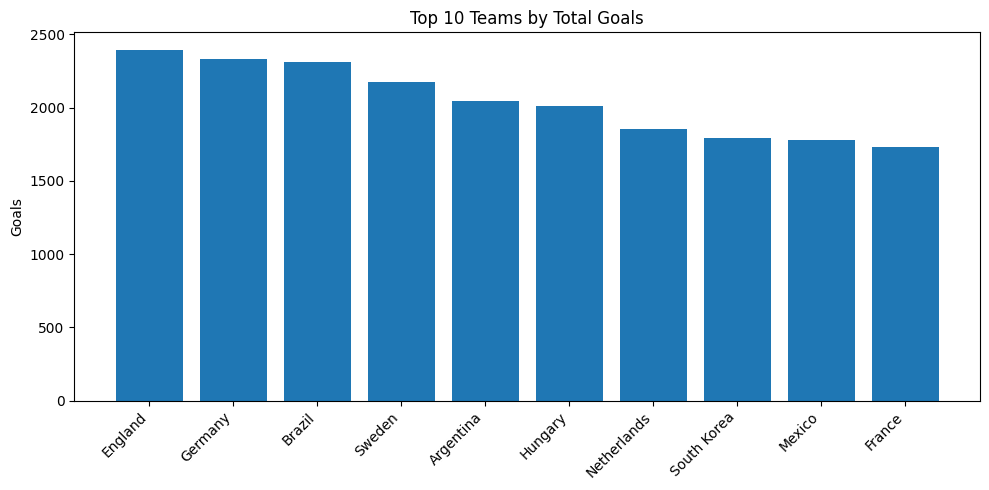

In [71]:
plt.figure(figsize=(10, 5))
plt.bar(top_10_teams['team'], top_10_teams['total_goals'])
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Teams by Total Goals')
plt.ylabel('Goals')
plt.tight_layout()
plt.show()


**Insight:** The top 10 by total goals and the top 10 individual goalscorers don't fully overlap — *(note which teams/players stand out, e.g. a team with fewer total goals than expected given how long it's been playing internationally, or a scorer whose total goals make up an unusually large share of their team's total)*. This distinguishes squad-wide scoring dominance from individual-player dominance.

### Objective 2: Team Efficiency

In [72]:
# Use a stricter threshold to avoid small-sample teams dominating the ranking.
min_matches = 250

home_stats = (
    df_results.groupby('home_team')
    .agg(
        matches_home=('home_team', 'size'),
        points_home=('home_points', 'sum'),
        goals_home=('home_score', 'sum'),))
away_stats = (
    df_results.groupby('away_team')
    .agg(
        matches_away=('away_team', 'size'),
        points_away=('away_points', 'sum'),
        goals_away=('away_score', 'sum'),))

team_stats = home_stats.join(away_stats, how='outer').fillna(0)
team_stats['matches_played'] = team_stats['matches_home'] + team_stats['matches_away']
team_stats['total_points'] = team_stats['points_home'] + team_stats['points_away']
team_stats['total_goals'] = team_stats['goals_home'] + team_stats['goals_away']
team_stats = team_stats.loc[team_stats['matches_played'] >= min_matches].copy()
team_stats['points_per_match'] = team_stats['total_points'] / team_stats['matches_played']
team_stats['goals_per_match'] = team_stats['total_goals'] / team_stats['matches_played']
team_stats.index.name = 'team'
team_stats = team_stats.reset_index()
top_efficient_teams = team_stats.sort_values('points_per_match', ascending=False)

display(top_efficient_teams[['team', 'matches_played', 'points_per_match', 'goals_per_match']].head(10))

,team,matches_played,points_per_match,goals_per_match
17,Brazil,1064.0,2.107143,2.175752
132,Spain,790.0,2.005063,2.044304
39,England,1097.0,1.958979,2.183227
51,Germany,1035.0,1.948792,2.252174
66,Iran,615.0,1.941463,1.882927
3,Argentina,1076.0,1.908922,1.902416
69,Italy,893.0,1.874580,1.752520
131,South Korea,1010.0,1.850495,1.776238
28,Croatia,400.0,1.842500,1.735000
120,Russia,749.0,1.805073,1.736983


**Insight:** After filtering to teams with at least 250 matches, the leaderboard is led by teams with sustained, long-run success rather than teams that simply played a lot of matches. *( a team that ranks high on points-per-match but noticeably lower on goals-per-match, suggesting a more defensive/efficiency-driven style rather than pure attacking dominance.)*

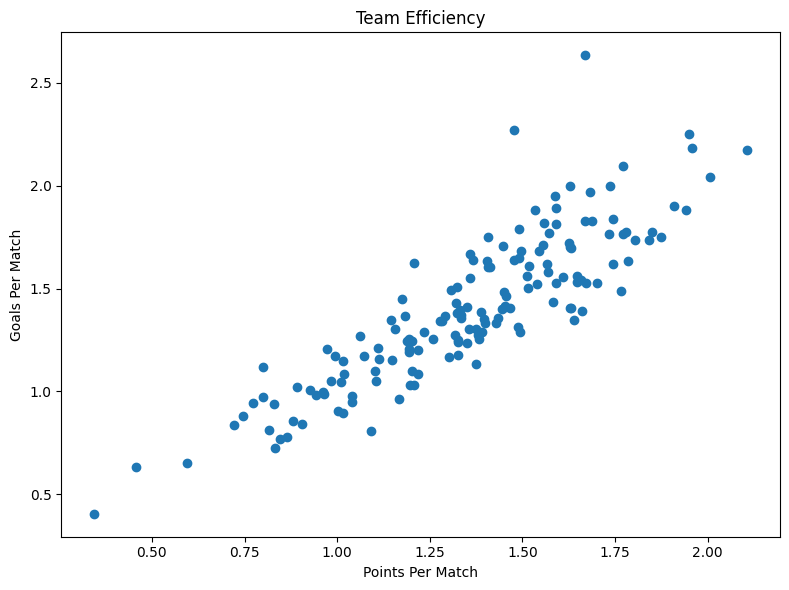

In [73]:
plt.figure(figsize=(8, 6))
plt.scatter(team_stats['points_per_match'], team_stats['goals_per_match'])
plt.title('Team Efficiency')
plt.xlabel('Points Per Match')
plt.ylabel('Goals Per Match')
plt.tight_layout()
plt.show()

### Objective 3: Drama Analysis

In [74]:
shootouts_by_decade = (
    df_shootouts.groupby('decade', as_index=False)
    .size()
    .rename(columns={'size': 'shootouts'})
    .sort_values('decade',ascending=False)
)



df_shootouts_with_tournament = df_shootouts.merge(
    df_results[['date', 'home_team', 'away_team', 'tournament']],
    on=['date', 'home_team', 'away_team'],
    how='left',
)
shootouts_by_tournament = (
    df_shootouts_with_tournament.groupby('tournament', as_index=False)
    .size()
    .rename(columns={'size': 'shootouts'})
    .sort_values('shootouts', ascending=False)
)


display(shootouts_by_decade)
display(shootouts_by_tournament)


,decade,shootouts
6,2020,124
5,2010,153
4,2000,144
3,1990,126
2,1980,97
1,1970,38
0,1960,1


,tournament,shootouts
42,Friendly,79
22,COSAFA Cup,63
5,African Cup of Nations,47
37,FIFA World Cup,39
25,Copa América,33
6,African Cup of Nations qualification,28
1,AFC Asian Cup,27
82,UEFA Euro,25
38,FIFA World Cup qualification,21
43,Gold Cup,18


### Objective 4: Worst Performers

In [75]:
first_goal_source = df_scorers.copy()
first_goal_source['minute'] = first_goal_source['minute'].fillna(9999)
first_goal_source = first_goal_source.sort_values(['date', 'home_team', 'away_team', 'minute', 'scorer'])
first_goal_idx = first_goal_source.groupby(['date', 'home_team', 'away_team'])['minute'].idxmin()
first_goals = first_goal_source.loc[first_goal_idx, ['date', 'home_team', 'away_team', 'team', 'scorer', 'minute']]

first_goal_matches = first_goals.merge(
    df_results[['date', 'home_team', 'away_team', 'home_points', 'away_points', 'home_score', 'away_score']],
    on=['date', 'home_team', 'away_team'],
    how='inner',
)

failed_to_win = first_goal_matches[
    ((first_goal_matches['team'] == first_goal_matches['home_team']) & (first_goal_matches['home_points'] <= 1))
    | ((first_goal_matches['team'] == first_goal_matches['away_team']) & (first_goal_matches['away_points'] <= 1))
]
worst_performers = (
    failed_to_win.groupby('team', as_index=False)
    .size()
    .rename(columns={'size': 'failed_to_win_count'})
    .sort_values('failed_to_win_count', ascending=False)
)

display(worst_performers.head(10))

,team,failed_to_win_count
26,Brazil,57
180,Switzerland,54
200,Uruguay,52
179,Sweden,51
155,Republic of Ireland,50
53,Denmark,49
175,Spain,49
148,Paraguay,48
18,Belgium,48
151,Poland,47


In [76]:

min_first_goals = 20  

times_scored_first = (
    first_goal_matches.groupby('team', as_index=False)
    .size()
    .rename(columns={'size': 'times_scored_first'})
)

worst_performers_rate = worst_performers.merge(times_scored_first, on='team', how='left')
worst_performers_rate['fail_rate'] = (
    worst_performers_rate['failed_to_win_count'] / worst_performers_rate['times_scored_first']
)
worst_performers_rate = worst_performers_rate.loc[
    worst_performers_rate['times_scored_first'] >= min_first_goals
].sort_values('fail_rate', ascending=False)

display(worst_performers_rate.head(10))


,team,failed_to_win_count,times_scored_first,fail_rate
70,Malta,23,36,0.638889
61,Luxembourg,25,51,0.490196
44,Cyprus,31,65,0.476923
60,Kazakhstan,25,54,0.462963
67,Thailand,24,52,0.461538
43,Venezuela,31,68,0.455882
129,Tanzania,9,20,0.450000
79,Moldova,22,49,0.448980
89,Faroe Islands,19,43,0.441860
118,Saint Vincent and the Grenadines,11,25,0.440000


**Insight:** The raw-count table above tends to surface teams with the most matches played overall. The rate-based table (failed-to-win ÷ times scored first) instead highlights teams that most often let a lead slip, regardless of sample size — *(fill in which teams top this list and whether it's the same names as the raw-count version)*.

### Objective 5: Era Comparison

In [77]:
era_base = df_results[['decade', 'total_goals', 'goal_margin', 'is_draw']].copy()
era_base['winning_margin'] = era_base['goal_margin'].where(~era_base['is_draw'])
era_comparison = (
    era_base.groupby('decade', as_index=False)
    .agg(
        Average_Goals_Per_Match=('total_goals', 'mean'),
        Draw_Rate=('is_draw', 'mean'),
        Average_Winning_Margin=('winning_margin', 'mean'),
    )
    .sort_values('decade')
)

most_lopsided_match = df_results.loc[df_results['goal_margin'] == df_results['goal_margin'].max(), [
    'date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'goal_margin'
]]

display(era_comparison)


,decade,Average_Goals_Per_Match,Draw_Rate,Average_Winning_Margin
0,1870,4.538462,0.153846,3.000000
1,1880,5.581818,0.090909,4.220000
2,1890,5.152542,0.152542,3.640000
3,1900,4.159420,0.173913,2.771930
4,1910,4.218182,0.160606,2.779783
5,1920,3.884477,0.179302,2.521994
6,1930,4.318814,0.159407,2.485116
7,1940,4.344538,0.153661,2.852482
8,1950,4.004240,0.183525,2.469585
9,1960,3.478963,0.196230,2.381072


**Outlier detection — most lopsided match ever played:**

In [78]:
display(most_lopsided_match)


,date,home_team,away_team,home_score,away_score,tournament,city,country,goal_margin
25425,2001-04-11,Australia,American Samoa,31.0,0.0,FIFA World Cup qualification,Coffs Harbour,Australia,31.0


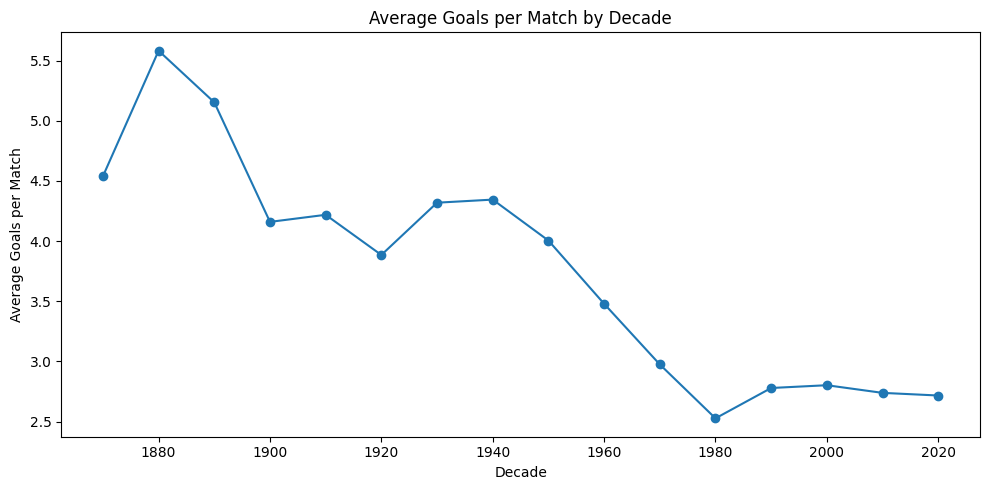

In [79]:
plt.figure(figsize=(10, 5))
plt.plot(era_comparison['decade'], era_comparison['Average_Goals_Per_Match'], marker='o')
plt.title('Average Goals per Match by Decade')
plt.xlabel('Decade')
plt.ylabel('Average Goals per Match')
plt.tight_layout()
plt.show()

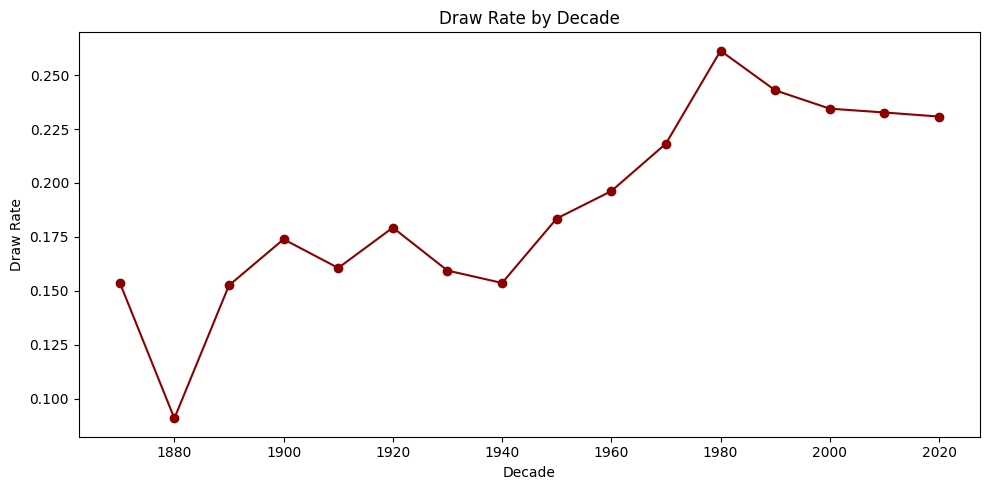

In [80]:
plt.figure(figsize=(10, 5))
plt.plot(era_comparison['decade'], era_comparison['Draw_Rate'], marker='o', color='darkred')
plt.title('Draw Rate by Decade')
plt.xlabel('Decade')
plt.ylabel('Draw Rate')
plt.tight_layout()
plt.show()